# Exploration Strategies: Epsilon-Greedy

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the exploration-exploitation dilemma
- Implement Epsilon-Greedy exploration strategy
- Visualize the impact of different epsilon values
- Compare exploration vs exploitation behavior on CartPole and FrozenLake (Parts 3c–3d: GIF + slider)
- Apply Epsilon-Greedy to RL problems

## 🔗 Prerequisites

- ✅ Gymnasium setup (previous notebook; successor to OpenAI Gym)
- ✅ Understanding of RL basics (actions, rewards, policies)
- ✅ Python knowledge (functions, loops, matplotlib)
- ✅ NumPy knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 1**:
- Exploration strategies: programming Epsilon-Greedy strategy and visualizing its impact

---

## Introduction

**Exploration-Exploitation Dilemma**: RL agents must balance exploring new actions (to discover better rewards) with exploiting known good actions (to maximize rewards). **Epsilon-Greedy** is a simple but effective exploration strategy.

If students see the word **Gym** in older material, interpret it here as **Gymnasium-style environment tooling** unless the notebook says otherwise.


## Lesson Brief

This lesson explains the exploration-exploitation dilemma through the simplest practical strategy: **epsilon-greedy**.

Students will see why an agent cannot only exploit what it already knows, and why some controlled exploration is necessary for learning.

Why this matters: this idea appears again in Q-learning, bandits, and deep RL.

If students understand this lesson well, many later design choices become easier to explain.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Jacob Schrum - "Q-Learning: What do those parameters mean? Epsilon, Gamma, and Alpha explained"**:
[Watch on YouTube](https://www.youtube.com/watch?v=XrxgdpduWOU)

Why this pick:
- short focused format.
- Explains epsilon-greedy in plain language without overcomplicating the math.
- Strong support for the exploration versus exploitation idea in this notebook.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


## What you should learn from this notebook

By the end of this notebook, you should be able to:

- explain the exploration-exploitation dilemma in plain language
- implement epsilon-greedy action selection
- understand how epsilon changes behavior
- use epsilon decay during learning
- recognize why this strategy is simple, useful, and imperfect


### Step Guide

**What this cell does:** Installs plotting/math helpers (`%pip`) and imports what the epsilon-greedy demos need.

**How to read it (weak Python OK):** If the cell ends quietly, you are ready. If `%pip` complains, fix that before any plots.

**What to expect in the output:** Pip logs and a friendly “libraries imported” confirmation.

**If you feel lost:** This is setup only—no exploration math yet.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install "gymnasium[classic-control]" numpy matplotlib ipywidgets pillow -q
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym  # successor to OpenAI Gym; API-compatible for imports

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nExploration Strategies: Epsilon-Greedy")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


Note: you may need to restart the kernel to use updated packages.
✅ Libraries imported!

Exploration Strategies: Epsilon-Greedy


## Part 1: Understanding Epsilon-Greedy Strategy


### Step Guide

**What this cell does:** **Part 1** — explains epsilon-greedy in words: with probability ε explore, else exploit the best-known action.

**How to read it (weak Python OK):** Translate ε to a habit: “I roll dice; sometimes I ignore my best idea on purpose.”

**What to expect in the output:** Printed rules of thumb about ε values and decay schedules.

**If you feel lost:** Write ε = 0.1 as “10% random, 90% greedy” in your notes—that one line unlocks the whole lesson.


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 1: Understanding Epsilon-Greedy Strategy")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nEpsilon-Greedy Algorithm:")
# Show text or numbers in the cell output area under the code.
print("  1. With probability ε (epsilon): Explore (choose random action)")
# Show text or numbers in the cell output area under the code.
print("  2. With probability 1-ε: Exploit (choose best known action)")

# Show text or numbers in the cell output area under the code.
print("\nKey Parameters:")
# Show text or numbers in the cell output area under the code.
print("  - ε (epsilon): Exploration rate (0.0 to 1.0)")
# Show text or numbers in the cell output area under the code.
print("  - ε = 1.0: Pure exploration (always random)")
# Show text or numbers in the cell output area under the code.
print("  - ε = 0.0: Pure exploitation (always greedy)")
# Show text or numbers in the cell output area under the code.
print("  - ε = 0.1: 10% exploration, 90% exploitation (common choice)")

# Show text or numbers in the cell output area under the code.
print("\nEpsilon Decay:")
# Show text or numbers in the cell output area under the code.
print("  - Start with high ε (more exploration)")
# Show text or numbers in the cell output area under the code.
print("  - Gradually decrease ε (more exploitation as agent learns)")
# Show text or numbers in the cell output area under the code.
print("  - Common: ε = 1.0 → 0.01 over training")

# Show text or numbers in the cell output area under the code.
print("\n✅ Epsilon-Greedy strategy understood!")


Part 1: Understanding Epsilon-Greedy Strategy

Epsilon-Greedy Algorithm:
  1. With probability ε (epsilon): Explore (choose random action)
  2. With probability 1-ε: Exploit (choose best known action)

Key Parameters:
  - ε (epsilon): Exploration rate (0.0 to 1.0)
  - ε = 1.0: Pure exploration (always random)
  - ε = 0.0: Pure exploitation (always greedy)
  - ε = 0.1: 10% exploration, 90% exploitation (common choice)

Epsilon Decay:
  - Start with high ε (more exploration)
  - Gradually decrease ε (more exploitation as agent learns)
  - Common: ε = 1.0 → 0.01 over training

✅ Epsilon-Greedy strategy understood!


## Part 2: Implementing Epsilon-Greedy


### Step Guide

**What this cell does:** **Part 2** — implements `epsilon_greedy_action` and runs a short scripted demo so you can **count explore vs exploit** decisions.

**How to read it (weak Python OK):** Watch the printed table of counts—does randomness match the ε you typed?

**What to expect in the output:** Step-by-step actions labeled explore/exploit plus totals.

**If you feel lost:** Change only `epsilon` and rerun; your counts should shift in a predictable direction.


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 2: Implementing Epsilon-Greedy")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


# Function `epsilon_greedy_action` (what it does): Return (action, mode) where mode is 'explore' or 'exploit'.
def epsilon_greedy_action(q_values, epsilon, n_actions):
    """Return (action, mode) where mode is 'explore' or 'exploit'."""
    # If the condition is True, run the indented block under this line.
    if np.random.random() < epsilon:
        # Send a value back to whoever called this function.
        return np.random.randint(n_actions), "explore"
    # Send a value back to whoever called this function.
    return int(np.argmax(q_values)), "exploit"


# Example: a tiny bandit-style decision problem
# Save a value in a name so the next lines can read it.
n_actions = 4
# Another assignment—same idea: store a value for the lines below.
q_values = np.array([0.1, 0.3, 0.5, 0.2])
# Another assignment—same idea: store a value for the lines below.
epsilon = 0.3

# Show text or numbers in the cell output area under the code.
print(f"\nExample estimated values: {q_values}")
# Show text or numbers in the cell output area under the code.
print(f"Epsilon: {epsilon}")
# Show text or numbers in the cell output area under the code.
print("\nRunning epsilon-greedy for 20 steps:")

# Save a value in a name so the next lines can read it.
action_counts = np.zeros(n_actions)
# Another assignment—same idea: store a value for the lines below.
mode_counts = {"explore": 0, "exploit": 0}
# Start a loop: repeat the indented block once per item in the sequence.
for i in range(20):
    # Save a value in a name so the next lines can read it.
    action, mode = epsilon_greedy_action(q_values, epsilon, n_actions)
    # Another assignment—same idea: store a value for the lines below.
    action_counts[action] += 1
    # Another assignment—same idea: store a value for the lines below.
    mode_counts[mode] += 1
    # Show text or numbers in the cell output area under the code.
    print(f"  Step {i + 1}: Action {action} ({mode})")

# Show text or numbers in the cell output area under the code.
print("\nAction selection counts:")
# Start a loop: repeat the indented block once per item in the sequence.
for i in range(n_actions):
    # Show text or numbers in the cell output area under the code.
    print(f"  Action {i}: {int(action_counts[i])} times ({action_counts[i] / 20 * 100:.1f}%)")

# Save a value in a name so the next lines can read it.
best_action = int(np.argmax(q_values))
# Show text or numbers in the cell output area under the code.
print(f"\nBest current action: {best_action}")
# Show text or numbers in the cell output area under the code.
print(f"Explore decisions: {mode_counts['explore']}")
# Show text or numbers in the cell output area under the code.
print(f"Exploit decisions: {mode_counts['exploit']}")
# Show text or numbers in the cell output area under the code.
print("\nCheckpoint: even when one action looks best, epsilon-greedy still tries")
# Show text or numbers in the cell output area under the code.
print("other actions sometimes so the agent can discover better choices later.")



Part 2: Implementing Epsilon-Greedy

Example estimated values: [0.1 0.3 0.5 0.2]
Epsilon: 0.3

Running epsilon-greedy for 20 steps:
  Step 1: Action 2 (exploit)
  Step 2: Action 2 (exploit)
  Step 3: Action 1 (explore)
  Step 4: Action 1 (explore)
  Step 5: Action 3 (explore)
  Step 6: Action 2 (exploit)
  Step 7: Action 2 (exploit)
  Step 8: Action 2 (exploit)
  Step 9: Action 2 (explore)
  Step 10: Action 0 (explore)
  Step 11: Action 3 (explore)
  Step 12: Action 2 (exploit)
  Step 13: Action 2 (exploit)
  Step 14: Action 2 (exploit)
  Step 15: Action 2 (exploit)
  Step 16: Action 2 (explore)
  Step 17: Action 2 (exploit)
  Step 18: Action 2 (exploit)
  Step 19: Action 2 (exploit)
  Step 20: Action 2 (exploit)

Action selection counts:
  Action 0: 1 times (5.0%)
  Action 1: 2 times (10.0%)
  Action 2: 15 times (75.0%)
  Action 3: 2 times (10.0%)

Best current action: 2
Explore decisions: 7
Exploit decisions: 13

Checkpoint: even when one action looks best, epsilon-greedy still trie

## Part 3: Visualizing Impact of Different Epsilon Values


### Step Guide

**What this cell does:** **Part 3** — plots how different ε values change how often each action is picked (same Q-values, different randomness).

**How to read it (weak Python OK):** Read the legend and axis titles before interpreting bar heights.

**What to expect in the output:** A matplotlib figure comparing exploration percentages.

**If you feel lost:** If the plot fails, rerun Part 2 first so `q_values` and counters exist.



Part 3: Visualizing Impact of Different Epsilon Values

Action selection percentages for different epsilon values:
Action | ε=0.0 | ε=0.1 | ε=0.3 | ε=0.5 | ε=1.0
--------------------------------------------------
  0 | 0.0% | 2.6% | 7.8% | 12.5% | 26.1%
  1 | 0.0% | 2.0% | 7.0% | 11.7% | 22.8%
  2 | 100.0% | 93.2% | 78.6% | 64.8% | 24.8% <- best estimate
  3 | 0.0% | 2.2% | 6.6% | 11.0% | 26.3%


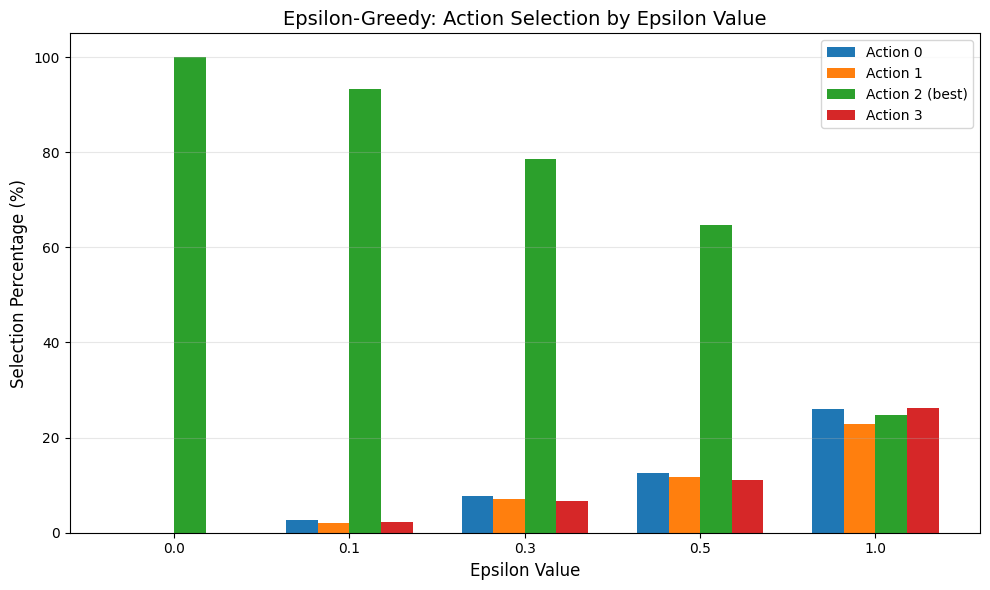


✅ Impact visualization complete!


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 3: Visualizing Impact of Different Epsilon Values")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Test different epsilon values
# Save a value in a name so the next lines can read it.
epsilon_values = [0.0, 0.1, 0.3, 0.5, 1.0]
# Another assignment—same idea: store a value for the lines below.
n_steps = 1000
# Another assignment—same idea: store a value for the lines below.
n_actions = 4
# Another assignment—same idea: store a value for the lines below.
q_values = np.array([0.1, 0.3, 0.5, 0.2])
# Another assignment—same idea: store a value for the lines below.
best_action = int(np.argmax(q_values))

# Another assignment—same idea: store a value for the lines below.
results = {}

# Start a loop: repeat the indented block once per item in the sequence.
for epsilon in epsilon_values:
    # Save a value in a name so the next lines can read it.
    action_counts = np.zeros(n_actions)
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(n_steps):
        # Save a value in a name so the next lines can read it.
        action, _ = epsilon_greedy_action(q_values, epsilon, n_actions)
        # Another assignment—same idea: store a value for the lines below.
        action_counts[action] += 1
    # Another assignment—same idea: store a value for the lines below.
    results[epsilon] = action_counts / n_steps

# Show text or numbers in the cell output area under the code.
print("\nAction selection percentages for different epsilon values:")
# Show text or numbers in the cell output area under the code.
print("Action | ε=0.0 | ε=0.1 | ε=0.3 | ε=0.5 | ε=1.0")
# Show text or numbers in the cell output area under the code.
print("-" * 50)
# Start a loop: repeat the indented block once per item in the sequence.
for i in range(n_actions):
    # Save a value in a name so the next lines can read it.
    percentages = [f"{results[eps][i] * 100:.1f}%" for eps in epsilon_values]
    # Another assignment—same idea: store a value for the lines below.
    marker = " <- best estimate" if i == best_action else ""
    # Show text or numbers in the cell output area under the code.
    print(f"  {i} | {' | '.join(percentages)}{marker}")

# Visualize
# Unpack Matplotlib figure and axes array created by subplots().
fig, ax = plt.subplots(figsize=(10, 6))
# Save a value in a name so the next lines can read it.
x = np.arange(len(epsilon_values))
# Another assignment—same idea: store a value for the lines below.
width = 0.18

# Start a loop: repeat the indented block once per item in the sequence.
for i in range(n_actions):
    # Save a value in a name so the next lines can read it.
    percentages = [results[eps][i] * 100 for eps in epsilon_values]
    # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
    label = f"Action {i}" + (" (best)" if i == best_action else "")
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(x + i * width, percentages, width, label=label)

# Same plot panel as the line above—one more small plotting tweak.
ax.set_xlabel('Epsilon Value', fontsize=12)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_ylabel('Selection Percentage (%)', fontsize=12)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_title('Epsilon-Greedy: Action Selection by Epsilon Value', fontsize=14)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_xticks(x + width * 1.5)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_xticklabels([str(eps) for eps in epsilon_values])
# Same plot panel as the line above—one more small plotting tweak.
ax.legend()
# Same plot panel as the line above—one more small plotting tweak.
ax.grid(True, alpha=0.3, axis='y')
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print("\n✅ Impact visualization complete!")


## Part 3b: Live ε sweep (interactive)

Drag **ε** and watch how action-selection percentages change **instantly** (same `epsilon_greedy_action` helper as Part 2). This is meant to build intuition faster than rerunning static plots for each value.

In [5]:
# Interactive ε: re-sample action counts whenever the slider moves.

if "epsilon_greedy_action" not in globals():
    raise RuntimeError("Run Part 2 above first so `epsilon_greedy_action` exists, then rerun this cell.")

import ipywidgets as widgets
from IPython.display import clear_output, display

# Same toy Q-vector as Part 3 (best action is index 2 with value 0.5).
n_actions = 4
q_demo = np.array([0.1, 0.3, 0.5, 0.2])
best_action = int(np.argmax(q_demo))
n_steps_mc = 1200

out = widgets.Output()


def mc_distribution(epsilon: float):
    counts = np.zeros(n_actions)
    for _ in range(n_steps_mc):
        a, _ = epsilon_greedy_action(q_demo, float(epsilon), n_actions)
        counts[a] += 1
    return counts / n_steps_mc


def draw(epsilon: float) -> None:
    import matplotlib.pyplot as plt

    with out:
        clear_output(wait=True)
        p = mc_distribution(epsilon)
        fig, ax = plt.subplots(figsize=(8.2, 4.4))
        colors = ["#16a34a" if i == best_action else "#94a3b8" for i in range(n_actions)]
        ax.bar(np.arange(n_actions), p * 100.0, color=colors)
        ax.set_ylim(0, 100)
        ax.set_xlabel("Action index")
        ax.set_ylabel("Approximate pick %")
        ax.set_title(f"ε-greedy — ε={epsilon:.2f}  (best Q is action {best_action})")
        for i, v in enumerate(p):
            ax.text(i, min(96.0, v * 100.0 + 2.0), f"{v * 100:.1f}%", ha="center", fontsize=10)
        plt.show()


eps_slider = widgets.FloatSlider(
    value=0.2, min=0.0, max=1.0, step=0.02, description="ε", readout_format=".2f"
)


def on_eps(change):
    draw(float(change["new"]))


eps_slider.observe(on_eps, names="value")
display(widgets.VBox([eps_slider, out]))
draw(float(eps_slider.value))

## Part 3c: Watch exploration on CartPole (GIF + step slider)

### Lesson Brief (why this is here)

Charts in Part 3 count *how often* each action is chosen. This part shows *what exploration looks like in motion* on a real Gymnasium environment.

We reuse the same `epsilon_greedy_action` helper from Part 2. The Q-vector here is a **tiny bias** toward pushing right (action `1`) at every step — not a full CartPole solution, just a fixed “habit” so exploitation is meaningful while exploration still injects random left/right tries.

**What to notice:** with **low ε**, motion looks steadier (mostly following the habit). With **high ε**, motion looks jittery (many random tries).

**Prerequisite:** run Part 2 first so `epsilon_greedy_action` exists.

### Step Guide

**What this cell does:** **Part 3c** — records CartPole frames under two ε settings and shows a GIF plus a step slider for each.

**How to read it (weak Python OK):** Watch motion first, numbers second. Jerky vs steady is the main signal.

**What to expect in the output:** Two short GIFs and two sliders (widgets). First run can take a few seconds.

**If you feel lost:** Re-run Part 2, then rerun this cell. If widgets do not appear, confirm `ipywidgets` is installed and Jupyter supports widgets.


In [ ]:
# Part 3c — connect epsilon-greedy to motion on CartPole (rgb_array frames).
# Run Part 2 first so `epsilon_greedy_action` is defined.

%pip install ipywidgets pillow -q

import pathlib
import sys

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError("Could not find course09_step_viz.py — open/run from inside Course 09.")

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz

if "epsilon_greedy_action" not in globals():
    raise RuntimeError("Run Part 2 first so `epsilon_greedy_action` exists, then rerun this cell.")

# Slight preference for action 1 (push right) at every step — a simple "habit" for exploitation to follow.
_q_cartpole_habit = np.array([-0.15, 0.15], dtype=float)
_n_actions_cartpole = 2


def _make_eps_policy(epsilon: float):
    def policy(obs, step):
        action, _mode = epsilon_greedy_action(_q_cartpole_habit, float(epsilon), _n_actions_cartpole)
        return int(action)

    return policy


def _rollout_cartpole_gif(epsilon: float, seed: int, *, max_steps: int = 140):
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    pol = _make_eps_policy(epsilon)
    frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
        env, pol, max_steps=max_steps, seed=seed
    )
    env.close()
    return frames, total_r, term, trunc


low_eps = 0.08
high_eps = 0.85

frames_low, ret_low, term_low, trunc_low = _rollout_cartpole_gif(low_eps, seed=0)
print(
    f"Low ε={low_eps:.2f}  | frames={len(frames_low)} | return={ret_low:.1f} | term={term_low} | trunc={trunc_low}"
)
print("\n--- Animated GIF (low ε: mostly exploitation of the habit) ---")
cs9viz.display_gif(frames_low, duration_ms=95)
cs9viz.display_step_slider(frames_low, title="CartPole — low ε timestep")

frames_high, ret_high, term_high, trunc_high = _rollout_cartpole_gif(high_eps, seed=3)
print(
    f"\nHigh ε={high_eps:.2f} | frames={len(frames_high)} | return={ret_high:.1f} | term={term_high} | trunc={trunc_high}"
)
print("\n--- Animated GIF (high ε: lots of random exploration) ---")
cs9viz.display_gif(frames_high, duration_ms=95)
cs9viz.display_step_slider(frames_high, title="CartPole — high ε timestep")

print(
    "\nTeaching read: compare jerkiness vs steadiness. Return is not the main lesson here — ε controls how often we break the habit."
)


## Part 3d: Same ε idea on a grid (FrozenLake)

### Lesson Brief

CartPole (Part 3c) shows **continuous motion**. FrozenLake shows **discrete grid moves** with the same ε-greedy rule.

We use `is_slippery=False` so the story stays readable for beginners. The Q-vector is again a **small fixed bias** (not a learned policy): it slightly prefers moving **down** at every state so exploitation is not “always pick action 0”.

### Step Guide

**What this cell does:** **Part 3d** — two short rollouts (low vs high ε) with GIF + slider, same helper as Part 2.

**How to read it (weak Python OK):** Watch how often the agent “wanders” off the bias direction when ε is high.

**What to expect in the output:** Two GIFs + two sliders.

**If you feel lost:** Run Part 2 first, then Part 3c, then this cell.

### Closing Takeaway (Parts 3c–3d)

ε is not only a bar chart: it changes **how often a policy breaks its current habit**. Same mechanism on a physics task (CartPole) and a grid task (FrozenLake).


In [ ]:
# Part 3d — FrozenLake rollouts (same epsilon_greedy_action as Part 2).

if "epsilon_greedy_action" not in globals():
    raise RuntimeError("Run Part 2 first so `epsilon_greedy_action` exists, then rerun this cell.")

if "cs9viz" not in globals() or "gym" not in globals():
    raise RuntimeError("Run the Part 3c cell first so `course09_step_viz` and `gymnasium` are imported.")

# Gymnasium FrozenLake-v1 actions: 0=left, 1=down, 2=right, 3=up
_q_lake_habit = np.array([0.02, 0.08, 0.02, 0.02], dtype=float)
_n_actions_lake = 4


def _make_lake_policy(epsilon: float):
    def policy(obs, step):
        action, _mode = epsilon_greedy_action(_q_lake_habit, float(epsilon), _n_actions_lake)
        return int(action)

    return policy


def _rollout_lake_gif(epsilon: float, seed: int, *, max_steps: int = 60):
    env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
    pol = _make_lake_policy(epsilon)
    frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
        env, pol, max_steps=max_steps, seed=seed
    )
    env.close()
    return frames, total_r, term, trunc


low_eps_lake = 0.10
high_eps_lake = 0.80

fl_low, r_low, t_low, tr_low = _rollout_lake_gif(low_eps_lake, seed=11)
print(
    f"FrozenLake low ε={low_eps_lake:.2f} | frames={len(fl_low)} | return={r_low:.1f} | term={t_low} | trunc={tr_low}"
)
print("\n--- GIF (low ε) ---")
cs9viz.display_gif(fl_low, duration_ms=280)
cs9viz.display_step_slider(fl_low, title="FrozenLake — low ε timestep")

fl_high, r_high, t_high, tr_high = _rollout_lake_gif(high_eps_lake, seed=22)
print(
    f"\nFrozenLake high ε={high_eps_lake:.2f} | frames={len(fl_high)} | return={r_high:.1f} | term={t_high} | trunc={tr_high}"
)
print("\n--- GIF (high ε) ---")
cs9viz.display_gif(fl_high, duration_ms=280)
cs9viz.display_step_slider(fl_high, title="FrozenLake — high ε timestep")


## Part 4: Epsilon Decay Strategy


### Step Guide

**What this cell does:** **Part 4** — walks through **epsilon decay** (start curious, end greedy) on a tiny bandit-style simulation.

**How to read it (weak Python OK):** Track how ε shrinks over episodes and how average reward creeps upward.

**What to expect in the output:** Text logs or small tables showing schedules and rewards.

**If you feel lost:** Ignore bandit details; only ask “did exploration shrink over time?” That is the lesson.



Part 4: Epsilon Decay Strategy


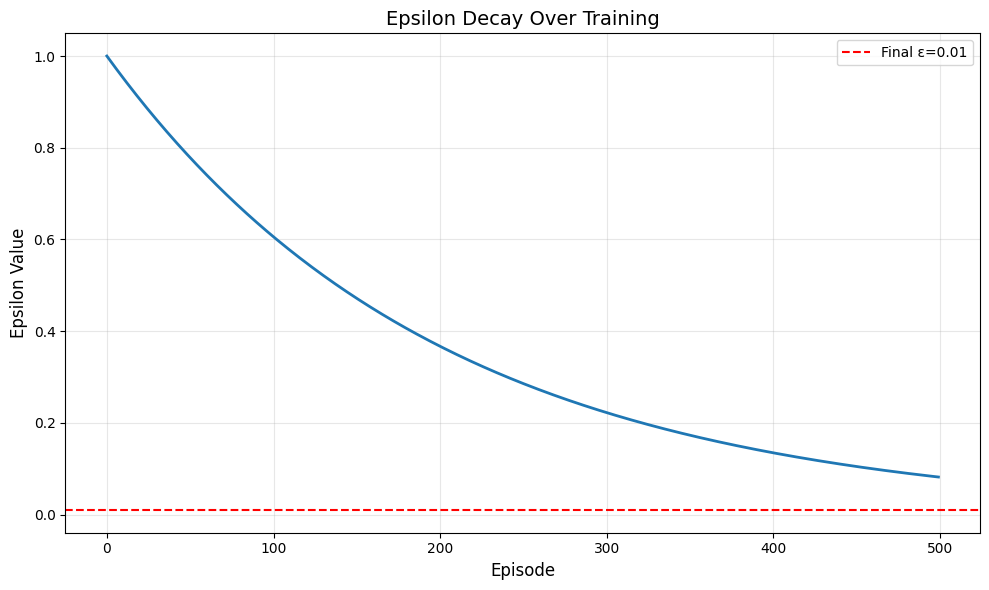


Epsilon Decay:
  Initial ε: 1.0
  Final ε: 0.01
  Decay rate: 0.995
  Episodes: 500
  ε at episode 100: 0.6058
  ε at episode 250: 0.2856
  ε at episode 500: 0.0820

✅ Epsilon decay strategy complete!


In [6]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 4: Epsilon Decay Strategy")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Function `epsilon_decay` (what it does): Calculate epsilon with exponential decay. Args: initial_epsilon: Starting epsilon value final_epsilon: Minimum epsilon value de...
def epsilon_decay(initial_epsilon, final_epsilon, decay_rate, episode):
    """
    Calculate epsilon with exponential decay.
    
    Args:
        initial_epsilon: Starting epsilon value
        final_epsilon: Minimum epsilon value
        decay_rate: Decay rate (0.0 to 1.0)
        episode: Current episode number
    
    Returns:
        Decayed epsilon value
    """
    # Send a value back to whoever called this function.
    return max(final_epsilon, initial_epsilon * (decay_rate ** episode))

# Simulate epsilon decay over training
# Save a value in a name so the next lines can read it.
initial_epsilon = 1.0
# Another assignment—same idea: store a value for the lines below.
final_epsilon = 0.01
# Another assignment—same idea: store a value for the lines below.
decay_rate = 0.995
# Another assignment—same idea: store a value for the lines below.
n_episodes = 500

# Another assignment—same idea: store a value for the lines below.
epsilon_history = []
# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(n_episodes):
    # Save a value in a name so the next lines can read it.
    epsilon = epsilon_decay(initial_epsilon, final_epsilon, decay_rate, episode)
    # Add one new item to the end of a list (the list grows in place).
    epsilon_history.append(epsilon)

# Visualize epsilon decay
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10, 6))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(epsilon_history, linewidth=2)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel('Episode', fontsize=12)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel('Epsilon Value', fontsize=12)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title('Epsilon Decay Over Training', fontsize=14)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.grid(True, alpha=0.3)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(y=final_epsilon, color='r', linestyle='--', label=f'Final ε={final_epsilon}')
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print(f"\nEpsilon Decay:")
# Show text or numbers in the cell output area under the code.
print(f"  Initial ε: {initial_epsilon}")
# Show text or numbers in the cell output area under the code.
print(f"  Final ε: {final_epsilon}")
# Show text or numbers in the cell output area under the code.
print(f"  Decay rate: {decay_rate}")
# Show text or numbers in the cell output area under the code.
print(f"  Episodes: {n_episodes}")
# Show text or numbers in the cell output area under the code.
print(f"  ε at episode 100: {epsilon_history[100]:.4f}")
# Show text or numbers in the cell output area under the code.
print(f"  ε at episode 250: {epsilon_history[250]:.4f}")
# Show text or numbers in the cell output area under the code.
print(f"  ε at episode 500: {epsilon_history[499]:.4f}")

# Show text or numbers in the cell output area under the code.
print("\n✅ Epsilon decay strategy complete!")


## Worked Example: A Small Bandit Problem

A bandit problem is a clean way to understand exploration.

Imagine a website team testing several button designs. Each design has an unknown
click-through rate. The system must decide:

- should it keep showing the design that currently looks best?
- or should it still test other designs in case one is better?

That is exactly the exploration-exploitation dilemma.

### Step Guide

**What this cell does:** Loads standard imports for any follow-on plots or checks (NumPy/Matplotlib helpers).

**How to read it (weak Python OK):** Another “tool belt” cell—no new RL concept, just libraries.

**What to expect in the output:** Usually silent aside from import side effects.

**If you feel lost:** If everything above ran, you can skim this cell quickly.



Epsilon = 0.0
 Arm pulls: [500   0   0]
 Estimated values: [0.126 0.    0.   ]
 Average reward: 0.126

Epsilon = 0.1
 Arm pulls: [ 53 377  70]
 Estimated values: [0.17  0.329 0.257]
 Average reward: 0.302

Epsilon = 0.3
 Arm pulls: [ 46 402  52]
 Estimated values: [0.152 0.366 0.346]
 Average reward: 0.344


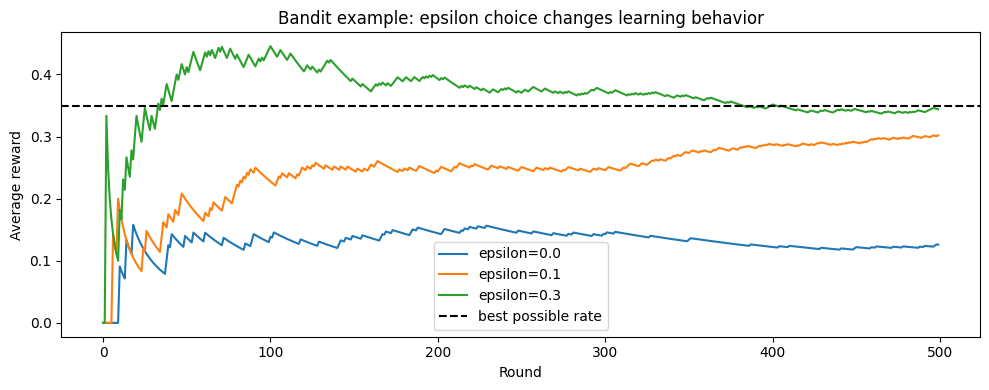


Teaching point:
- epsilon=0.0 can get stuck exploiting too early.
- a small epsilon often learns more safely.
- a very large epsilon explores a lot, but may exploit too slowly.


In [7]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Save a value in a name so the next lines can read it.
TRUE_RATES = np.array([0.15, 0.35, 0.25])
# Another assignment—same idea: store a value for the lines below.
N_ARMS = len(TRUE_RATES)
# Another assignment—same idea: store a value for the lines below.
N_ROUNDS = 500


# Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: arm.
def pull(arm):
    # Send a value back to whoever called this function.
    return 1 if np.random.rand() < TRUE_RATES[arm] else 0


# Function `run_epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: epsilon.
def run_epsilon_greedy(epsilon):
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS)
    # Another assignment—same idea: store a value for the lines below.
    value_estimates = np.zeros(N_ARMS)
    # Unpack the one-step model output from transition(state, action).
    rewards = []

    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        action, _ = epsilon_greedy_action(value_estimates, epsilon, N_ARMS)
        # Unpack the one-step model output from transition(state, action).
        reward = pull(action)
        # Save a value in a name so the next lines can read it.
        counts[action] += 1
        # Another assignment—same idea: store a value for the lines below.
        value_estimates[action] += (reward - value_estimates[action]) / counts[action]
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)

    # Send a value back to whoever called this function.
    return counts, value_estimates, np.array(rewards)


# Save a value in a name so the next lines can read it.
results = {}
# Start a loop: repeat the indented block once per item in the sequence.
for epsilon in [0.0, 0.1, 0.3]:
    # Save a value in a name so the next lines can read it.
    counts, estimates, rewards = run_epsilon_greedy(epsilon)
    # Another assignment—same idea: store a value for the lines below.
    results[epsilon] = (counts, estimates, rewards)
    # Show text or numbers in the cell output area under the code.
    print(f"\nEpsilon = {epsilon}")
    # Show text or numbers in the cell output area under the code.
    print(" Arm pulls:", counts.astype(int))
    # Show text or numbers in the cell output area under the code.
    print(" Estimated values:", np.round(estimates, 3))
    # Show text or numbers in the cell output area under the code.
    print(" Average reward:", rewards.mean().round(3))

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10, 4))
# Start a loop: repeat the indented block once per item in the sequence.
for epsilon, (_, _, rewards) in results.items():
    # Save a value in a name so the next lines can read it.
    running_average = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(running_average, label=f"epsilon={epsilon}")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(TRUE_RATES.max(), linestyle="--", color="black", label="best possible rate")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Round")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Average reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Bandit example: epsilon choice changes learning behavior")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("- epsilon=0.0 can get stuck exploiting too early.")
# Show text or numbers in the cell output area under the code.
print("- a small epsilon often learns more safely.")
# Show text or numbers in the cell output area under the code.
print("- a very large epsilon explores a lot, but may exploit too slowly.")


## Summary

You learned the first core exploration strategy used throughout RL:

- **epsilon-greedy** explores with probability `epsilon`
- otherwise it exploits the best current action estimate

### What to remember

- Exploration is necessary because the agent does not know the best action at the start.
- Exploitation is necessary because the agent must eventually use what it has learned.
- Epsilon decay is a practical way to move from more exploration to more exploitation over time.

### Important limitation

Epsilon-greedy is simple and useful, but it is not always the most efficient strategy.
More advanced exploration methods appear later in Unit 4.

### Next step

Move to `06_solving_rl_problems_states_actions_rewards.ipynb` or, if you already completed it,
continue to `07_mini_projects_cartpole_frozenlake_qlearning_dqn.ipynb`. 

In [8]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

### State-of-the-art ε-greedy and UCB are still dominant in industry A/B testing systems.
"""))


## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

### State-of-the-art ε-greedy and UCB are still dominant in industry A/B testing systems.


### Step Guide

**What this cell does:** Optional **auto-plots** summarizing numeric artifacts from the epsilon experiments.

**How to read it (weak Python OK):** Use charts to confirm patterns you already saw in prints.

**What to expect in the output:** Figures or a no-op message.

**If you feel lost:** Re-run Parts 2–4 so variables exist, then try this cell again.


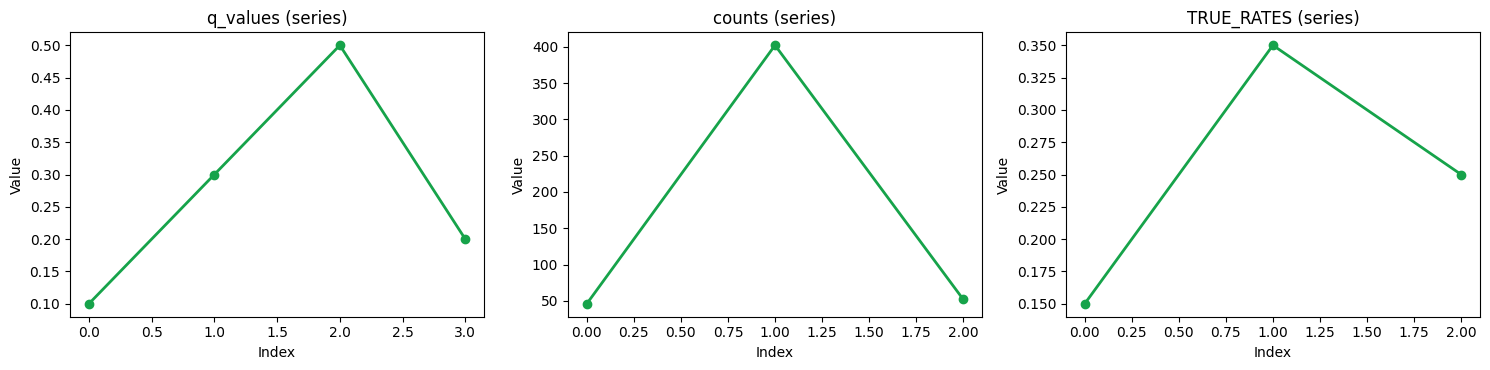

In [9]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Epsilon-greedy balances trying what looks best now with occasionally exploring alternatives that may become better later.

**If students remember one idea:** Exploration is not randomness for its own sake. It is a strategy for avoiding premature confidence.

**Quick check before moving on:**
- Can you explain what happens when epsilon is too high or too low?
- Can you tell when an action was chosen for exploration versus exploitation?

**Bridge to the next step:** Next, you will step back and learn how to formulate RL problems before choosing the right algorithm.

**For weaker coders:** If you can explain ε as “how often I try something random on purpose,” you already grasp epsilon-greedy; everything else is practice.
